# Day 48 (2/2) — Decision Tree Regression

Same flowchart of yes/no questions, but each **leaf predicts a number**: the **average** of the training targets
that land in it.

### In this notebook
1. Train a regression tree and predict a salary
2. See the **staircase** prediction curve
3. Read the tree
4. How `max_depth` changes the staircase
5. A key limitation: trees cannot extrapolate

> 📖 Theory: [`theory.md`](theory.md) §6 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset[['Level']].values        # 2-D: one feature column
y = dataset['Salary'].values
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


**Position Salaries:** 10 job levels and their salaries. It is a tiny demo dataset, so there is **no train/test
split**: we use it to *see* how each model draws its curve. The question: *a new hire says they were at level 6.5 and
earned 160,000. Is that believable?*

## 1. Train and predict

> ✍️ **Core code: learn this.** `DecisionTreeRegressor` works exactly like the classifier.

In [3]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor(random_state=0)
regressor.fit(X, y)

print("Predicted salary for level 6.5:", regressor.predict([[6.5]])[0])

Predicted salary for level 6.5: 150000.0


The tree predicts **150,000**, exactly the salary of level 6. With no depth limit and only 10 points, every level
gets its **own leaf**, and 6.5 falls into level 6's leaf (the split sits halfway between levels, at 6.5).

## 2. The staircase

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

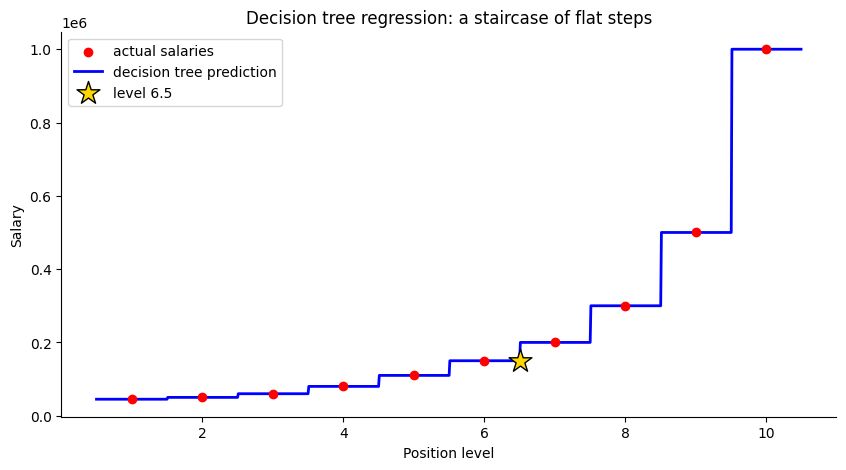

In [4]:
X_grid = np.arange(0.5, 10.5, 0.01).reshape(-1, 1)

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='red', zorder=3, label='actual salaries')
plt.plot(X_grid, regressor.predict(X_grid), color='blue', linewidth=2, label='decision tree prediction')
plt.scatter([6.5], regressor.predict([[6.5]]), marker='*', s=300, color='gold', edgecolor='k', zorder=4,
            label='level 6.5')
plt.title('Decision tree regression: a staircase of flat steps')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.legend()
plt.show()

A regression tree's prediction is **piecewise constant**: flat steps, one per leaf. Within a leaf, every input gets
the same prediction (the leaf's average). Always plot it on a **fine grid** like this; plotting only at the 10 data
points would hide the steps and look like a smooth line.

## 3. Read a small tree

> ✍️ **Core code: learn this.** Limit the depth and print the rules.

In [5]:
from sklearn.tree import export_text

small = DecisionTreeRegressor(max_depth=2, random_state=0).fit(X, y)
print(export_text(small, feature_names=['Level']))

|--- Level <= 8.50
|   |--- Level <= 6.50
|   |   |--- value: [82500.00]
|   |--- Level >  6.50
|   |   |--- value: [250000.00]
|--- Level >  8.50
|   |--- Level <= 9.50
|   |   |--- value: [500000.00]
|   |--- Level >  9.50
|   |   |--- value: [1000000.00]



Each leaf's `value` is the **average salary** of the training levels inside it. The first split (Level ≤ 8.5) separates the two
highest-paid levels (9 and 10) from the rest, because that split reduces the squared error the most.

## 4. How depth changes the staircase

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

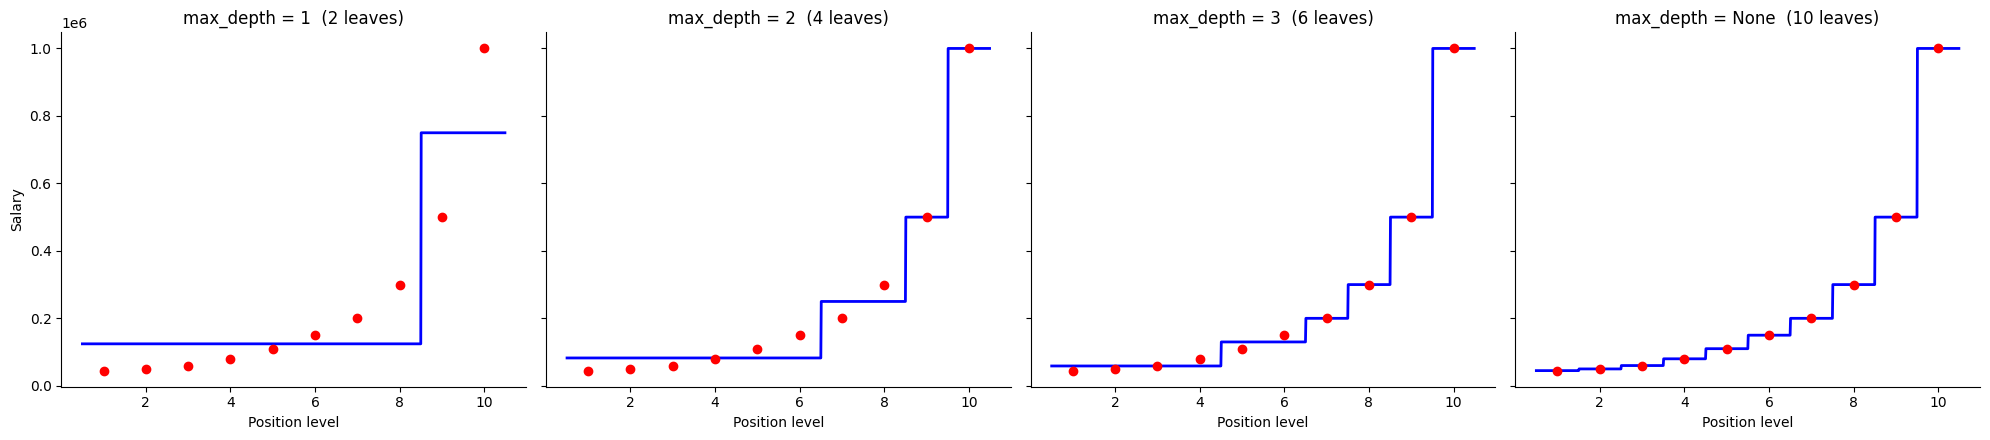

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for ax, d in zip(axes, [1, 2, 3, None]):
    m = DecisionTreeRegressor(max_depth=d, random_state=0).fit(X, y)
    ax.scatter(X, y, color='red', zorder=3)
    ax.plot(X_grid, m.predict(X_grid), color='blue', linewidth=2)
    ax.set_title(f'max_depth = {d}  ({m.get_n_leaves()} leaves)')
    ax.set_xlabel('Position level')
axes[0].set_ylabel('Salary')
plt.tight_layout()
plt.show()

- **Depth 1:** one question, two steps: very rough (underfitting).
- **Deeper:** more steps that follow the data more closely.
- **No limit:** one step per data point: it reproduces the training data exactly, which on real data means overfitting.

## 5. Limitation: no extrapolation

In [7]:
for level in [10, 12, 20]:
    print(f"Level {level:>2}: predicted salary = {regressor.predict([[level]])[0]:,.0f}")

Level 10: predicted salary = 1,000,000
Level 12: predicted salary = 1,000,000
Level 20: predicted salary = 1,000,000


A tree can only output averages of values it has **seen**. Beyond the training range it keeps predicting the last
leaf (1,000,000), however far you go. Linear and polynomial models would continue the trend.

---
## Key takeaways
- Regression trees split to **reduce squared error** and predict the **average** of each leaf.
- Predictions form a **staircase**; deeper trees have more, smaller steps.
- No scaling needed; limit depth to avoid overfitting.
- Trees **cannot extrapolate** beyond the training range.

➡️ **Next:** Ensemble Learning: start at [`../ensemble-learning/`](../ensemble-learning/) (Random Forest is `04-random-forest/`): many trees voting together, for better accuracy and stability.